# Добровольский А.В. ИУ5-23М
## Лабораторная работа №4

**Тема:** методы поиска условного экстремума.

Реализованы методы:

1. метод штрафных функций;
2. метод барьерных функций;
3. комбинированный метод штрафных и барьерных функций;
4. метод модифицированной функции Лагранжа;
5. метод проекции градиента.



## 1. Импорт библиотек

In [1]:
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import root

pd.set_option('display.precision', 10)


## 2. Параметры варианта и ограничения

In [ ]:


a, b, f0, n, R = 250, 2, 50, 2, 2

print(f'Вариант 4: a={a}, b={b}, f0={f0}, n={n}')
print(f'Ограничения: x1^2 + x2^2 - {R} <= 0, -x1 <= 0, -x2 <= 0')


Вариант 4: a=250, b=2, f0=50, n=2
Ограничения: x1^2 + x2^2 - 2 <= 0, -x1 <= 0, -x2 <= 0


## 3. Функция Розенброка, градиент и ограничения

In [3]:
def rosenbrock(x):
    """Обобщенная функция Розенброка."""
    x = np.asarray(x, dtype=float)
    return float(np.sum(a * (x[1:] - x[:-1]**2)**2 + b * (x[:-1] - 1)**2) + f0)


def grad_rosenbrock(x):
    """Аналитический градиент обобщенной функции Розенброка."""
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    for i in range(len(x) - 1):
        t = x[i + 1] - x[i]**2
        grad[i] += -4 * a * x[i] * t + 2 * b * (x[i] - 1)
        grad[i + 1] += 2 * a * t
    return grad


def constraints_g(x):
    """Вектор ограничений g(x)<=0 для выбранного двумерного варианта."""
    x = np.asarray(x, dtype=float)
    return np.array([
        x[0]**2 + x[1]**2 - R,
        -x[0],
        -x[1],
    ], dtype=float)


def constraints_jacobian(x):
    """Якобиан ограничений: строки - градиенты g_j(x)."""
    x = np.asarray(x, dtype=float)
    return np.array([
        [2 * x[0], 2 * x[1]],
        [-1.0, 0.0],
        [0.0, -1.0],
    ], dtype=float)


def violation(x):
    """Евклидова норма положительной части ограничений."""
    return float(np.linalg.norm(np.maximum(0.0, constraints_g(x))))


def is_feasible(x, tol=1e-8):
    return np.all(constraints_g(x) <= tol)


x0_outside = np.array([-1.2, 1.0])
x0_inside = np.array([0.5, 0.5])

print('Начальная точка для внешних методов:', x0_outside)
print('Начальная внутренняя допустимая точка:', x0_inside)
print('g(x0_inside)=', constraints_g(x0_inside))


Начальная точка для внешних методов: [-1.2  1. ]
Начальная внутренняя допустимая точка: [0.5 0.5]
g(x0_inside)= [-1.5 -0.5 -0.5]


## 4. Поиск KKT-стационарных точек

In [4]:
def find_kkt_points():
    """Поиск KKT-стационарных точек перебором активных ограничений."""
    candidates = []
    m = len(constraints_g(np.zeros(n)))
    grid = np.linspace(0, np.sqrt(R), 7)
    starts = [np.array(p, dtype=float) for p in itertools.product(grid, repeat=n)]

    for active_size in range(min(n, m) + 1):
        for active in itertools.combinations(range(m), active_size):
            p = len(active)

            def equations(z):
                x = z[:n]
                lam = z[n:]
                stationarity = grad_rosenbrock(x)
                if p:
                    stationarity = stationarity + constraints_jacobian(x)[list(active)].T @ lam
                active_eq = constraints_g(x)[list(active)] if p else []
                return np.r_[stationarity, active_eq]

            for start in starts:
                z0 = np.r_[start, np.ones(p) * 0.1]
                sol = root(equations, z0)
                if not sol.success or np.linalg.norm(equations(sol.x)) >= 1e-6:
                    continue

                x = sol.x[:n]
                lam = sol.x[n:]
                g_val = constraints_g(x)

                if np.all(g_val <= 1e-5) and np.all(lam >= -1e-5):
                    full_lam = np.zeros(m)
                    full_lam[list(active)] = lam
                    complementarity = abs(full_lam @ g_val)
                    if complementarity < 1e-5:
                        if all(np.linalg.norm(x - item['x']) > 1e-5 for item in candidates):
                            candidates.append({
                                'x': x,
                                'f(x)': rosenbrock(x),
                                'g(x)': g_val,
                                'lambda': full_lam,
                                'stationarity_norm': np.linalg.norm(
                                    grad_rosenbrock(x) + constraints_jacobian(x).T @ full_lam
                                ),
                            })

    return sorted(candidates, key=lambda item: item['f(x)'])


kkt_points = find_kkt_points()
kkt_df = pd.DataFrame([
    {
        'x': np.array2string(item['x'], precision=8),
        'f(x)': item['f(x)'],
        'g(x)': np.array2string(item['g(x)'], precision=8),
        'lambda': np.array2string(item['lambda'], precision=8),
        'stationarity_norm': item['stationarity_norm'],
    }
    for item in kkt_points
])
kkt_df


,x,f(x),g(x),lambda,stationarity_norm
0,[1. 1.],50.0,[ 1.7188917e-11 -1.0000000e+00 -1.0000000e+00],[0. 0. 0.],1.7717891625e-11


## 5. Внутренний метод безусловной оптимизации

In [5]:
def bfgs_unconstrained(fun_grad, x0, domain=None, maxiter=1000, tol=1e-8):
    """Внутренний BFGS-поиск для вспомогательных безусловных задач."""
    x = np.asarray(x0, dtype=float).copy()
    n_dim = len(x)
    H = np.eye(n_dim)
    f_val, grad_val = fun_grad(x)
    n_eval = 1

    for iteration in range(1, maxiter + 1):
        if np.linalg.norm(grad_val) <= tol:
            break

        direction = -H @ grad_val
        if float(grad_val @ direction) >= 0 or not np.all(np.isfinite(direction)):
            H = np.eye(n_dim)
            direction = -grad_val

        directional_derivative = float(grad_val @ direction)
        alpha = 1.0
        accepted = False

        for _ in range(80):
            x_new = x + alpha * direction
            if domain is None or domain(x_new):
                f_new, grad_new = fun_grad(x_new)
                n_eval += 1
                if np.isfinite(f_new) and f_new <= f_val + 1e-4 * alpha * directional_derivative:
                    accepted = True
                    break
            alpha *= 0.5

        if not accepted:
            break

        s = x_new - x
        y = grad_new - grad_val
        sy = float(s @ y)

        if sy > 1e-12:
            rho = 1.0 / sy
            I = np.eye(n_dim)
            V = I - rho * np.outer(s, y)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            H = np.eye(n_dim)

        x, f_val, grad_val = x_new, f_new, grad_new

        if np.linalg.norm(s) < 1e-12:
            break

    return x, {
        'nit': iteration,
        'nfev': n_eval,
        'fun': f_val,
        'jac': grad_val,
        'success': np.linalg.norm(grad_val) <= tol,
    }


## 6. Методы условной оптимизации

In [6]:
def method_penalty(x0, r0=1.0, C=8.0, eps=1e-8, max_outer=20):
    """Метод внешних штрафных функций."""
    history = []
    x = np.asarray(x0, dtype=float)
    r = r0
    start_time = time.perf_counter()
    total_inner = 0

    for k in range(max_outer):
        def FG(z):
            g_val = constraints_g(z)
            J = constraints_jacobian(z)
            positive = np.maximum(0.0, g_val)
            F = rosenbrock(z) + 0.5 * r * np.dot(positive, positive)
            grad_F = grad_rosenbrock(z) + r * (J.T @ positive)
            return F, grad_F

        x_new, res = bfgs_unconstrained(FG, x)
        total_inner += res['nit']
        positive = np.maximum(0.0, constraints_g(x_new))
        penalty_value = 0.5 * r * np.dot(positive, positive)

        history.append({
            'outer': k,
            'x': x_new.copy(),
            'f': rosenbrock(x_new),
            'F': FG(x_new)[0],
            'r': r,
            'aux': penalty_value,
            'viol': violation(x_new),
            'inner_iter': res['nit'],
        })

        if penalty_value <= eps and violation(x_new) <= 1e-5:
            break

        x = x_new
        r *= C

    return {
        'method': 'Штрафные функции',
        'x': history[-1]['x'],
        'f': history[-1]['f'],
        'viol': history[-1]['viol'],
        'outer_iter': len(history),
        'inner_iter': total_inner,
        'time_sec': time.perf_counter() - start_time,
        'history': history,
    }


def method_barrier(x0, r0=1.0, C=8.0, eps=1e-8, max_outer=18):
    """Метод внутренних барьерных функций с логарифмическим барьером."""
    history = []
    x = np.asarray(x0, dtype=float)
    r = r0
    start_time = time.perf_counter()
    total_inner = 0
    domain = lambda z: np.all(constraints_g(z) < -1e-12)

    for k in range(max_outer):
        def FG(z):
            g_val = constraints_g(z)
            J = constraints_jacobian(z)
            F = rosenbrock(z) - r * np.sum(np.log(-g_val))
            grad_F = grad_rosenbrock(z) - r * (J.T @ (1.0 / g_val))
            return F, grad_F

        x_new, res = bfgs_unconstrained(FG, x, domain=domain, maxiter=1500)
        total_inner += res['nit']
        g_val = constraints_g(x_new)
        barrier_value = float(-r * np.sum(np.log(-g_val))) if np.all(g_val < 0) else np.inf

        history.append({
            'outer': k,
            'x': x_new.copy(),
            'f': rosenbrock(x_new),
            'F': FG(x_new)[0],
            'r': r,
            'aux': barrier_value,
            'viol': violation(x_new),
            'inner_iter': res['nit'],
        })

        if r <= eps:
            break

        x = x_new
        r /= C

    return {
        'method': 'Барьерные функции',
        'x': history[-1]['x'],
        'f': history[-1]['f'],
        'viol': history[-1]['viol'],
        'outer_iter': len(history),
        'inner_iter': total_inner,
        'time_sec': time.perf_counter() - start_time,
        'history': history,
    }


def method_combined(x0, R0=1.0, r0=1.0, C=8.0, eps=1e-8, max_outer=18):
    """Комбинированный метод: внешний штраф + внутренний логарифмический барьер."""
    history = []
    x = np.asarray(x0, dtype=float)
    R_penalty = R0
    r_barrier = r0
    start_time = time.perf_counter()
    total_inner = 0
    domain = lambda z: np.all(constraints_g(z) < -1e-12)

    for k in range(max_outer):
        def FG(z):
            g_val = constraints_g(z)
            J = constraints_jacobian(z)
            positive = np.maximum(0.0, g_val)
            F = rosenbrock(z)
            F += 0.5 * R_penalty * np.dot(positive, positive)
            F += -r_barrier * np.sum(np.log(-g_val))
            grad_F = grad_rosenbrock(z)
            grad_F += R_penalty * (J.T @ positive)
            grad_F += -r_barrier * (J.T @ (1.0 / g_val))
            return F, grad_F

        x_new, res = bfgs_unconstrained(FG, x, domain=domain, maxiter=1500)
        total_inner += res['nit']

        history.append({
            'outer': k,
            'x': x_new.copy(),
            'f': rosenbrock(x_new),
            'F': FG(x_new)[0],
            'r_barrier': r_barrier,
            'R_penalty': R_penalty,
            'aux': abs(FG(x_new)[0] - rosenbrock(x_new)),
            'viol': violation(x_new),
            'inner_iter': res['nit'],
        })

        if r_barrier <= eps and violation(x_new) <= 1e-6:
            break

        x = x_new
        r_barrier /= C
        R_penalty *= C

    return {
        'method': 'Комбинированный метод',
        'x': history[-1]['x'],
        'f': history[-1]['f'],
        'viol': history[-1]['viol'],
        'outer_iter': len(history),
        'inner_iter': total_inner,
        'time_sec': time.perf_counter() - start_time,
        'history': history,
    }


def method_aug_lagrangian(x0, r0=1.0, C=4.0, max_outer=25):
    """Метод модифицированной функции Лагранжа для ограничений g(x)<=0."""
    history = []
    x = np.asarray(x0, dtype=float)
    r = r0
    mu = np.zeros(len(constraints_g(x)))
    start_time = time.perf_counter()
    total_inner = 0

    for k in range(max_outer):
        def FG(z):
            g_val = constraints_g(z)
            J = constraints_jacobian(z)
            q = mu + r * g_val
            q_positive = np.maximum(0.0, q)
            F = rosenbrock(z) + (np.dot(q_positive, q_positive) - np.dot(mu, mu)) / (2 * r)
            grad_F = grad_rosenbrock(z) + J.T @ q_positive
            return F, grad_F

        x_new, res = bfgs_unconstrained(FG, x)
        total_inner += res['nit']
        g_val = constraints_g(x_new)
        mu_new = np.maximum(0.0, mu + r * g_val)
        complementarity = float(np.linalg.norm(mu_new * g_val))

        history.append({
            'outer': k,
            'x': x_new.copy(),
            'f': rosenbrock(x_new),
            'F': FG(x_new)[0],
            'r': r,
            'mu': mu_new.copy(),
            'aux': complementarity,
            'viol': violation(x_new),
            'inner_iter': res['nit'],
        })

        if violation(x_new) <= 1e-7 and complementarity <= 1e-6 and (
            k > 0 and np.linalg.norm(x_new - x) <= 1e-7
        ):
            break

        x = x_new
        mu = mu_new
        if violation(x_new) > 1e-5:
            r *= C

    return {
        'method': 'Модиф. Лагранж',
        'x': history[-1]['x'],
        'f': history[-1]['f'],
        'viol': history[-1]['viol'],
        'outer_iter': len(history),
        'inner_iter': total_inner,
        'time_sec': time.perf_counter() - start_time,
        'history': history,
    }


def project_feasible(y):
    """Проекция на область X={x1^2+x2^2<=R, x1>=0, x2>=0}."""
    z = np.maximum(np.asarray(y, dtype=float), 0.0)
    radius = np.sqrt(R)
    norm = np.linalg.norm(z)
    if norm > radius:
        z = z / norm * radius
    return z


def method_projected_gradient(x0, eps=1e-8, max_iter=20000):
    """Метод проекции градиента."""
    x = project_feasible(x0)
    history = [{
        'iter': 0,
        'x': x.copy(),
        'f': rosenbrock(x),
        'viol': violation(x),
        'step_norm': np.nan,
        'alpha': np.nan,
    }]
    start_time = time.perf_counter()

    for k in range(1, max_iter + 1):
        grad = grad_rosenbrock(x)
        alpha = 1.0
        f_old = rosenbrock(x)

        for _ in range(80):
            y = project_feasible(x - alpha * grad)
            step = np.linalg.norm(y - x)
            if rosenbrock(y) <= f_old - 1e-4 * step * step / max(alpha, 1e-300) or step < 1e-15:
                break
            alpha *= 0.5

        x_new = y
        history.append({
            'iter': k,
            'x': x_new.copy(),
            'f': rosenbrock(x_new),
            'viol': violation(x_new),
            'step_norm': np.linalg.norm(x_new - x),
            'alpha': alpha,
        })

        if np.linalg.norm(x_new - x) <= eps:
            x = x_new
            break

        x = x_new

    return {
        'method': 'Проекция градиента',
        'x': history[-1]['x'],
        'f': history[-1]['f'],
        'viol': history[-1]['viol'],
        'outer_iter': len(history) - 1,
        'inner_iter': 0,
        'time_sec': time.perf_counter() - start_time,
        'history': history,
    }


## 7. Запуск методов и сравнение

In [7]:
methods = [
    method_penalty(x0_outside),
    method_barrier(x0_inside),
    method_combined(x0_inside),
    method_aug_lagrangian(x0_outside),
    method_projected_gradient(x0_inside),
]

results_df = pd.DataFrame([
    {
        'Метод': result['method'],
        'x': np.array2string(result['x'], precision=8),
        'f(x)': result['f'],
        'Нарушение ограничений': result['viol'],
        'Внешние итерации': result['outer_iter'],
        'Внутренние итерации': result['inner_iter'],
        'Время, с': result['time_sec'],
    }
    for result in methods
]).sort_values(['Время, с', 'Внешние итерации'])

results_df


,Метод,x,f(x),Нарушение ограничений,Внешние итерации,Внутренние итерации,"Время, с"
3,Модиф. Лагранж,[1. 1.],50.0000000000,0.0,2,44,0.0042881
0,Штрафные функции,[1. 1.],50.0000000000,0.0,1,43,0.0052703
1,Барьерные функции,[0.99995686 0.99991361],50.0000000037,0.0,10,167,0.0530814
2,Комбинированный метод,[0.99995686 0.99991361],50.0000000037,0.0,10,167,0.0537974
4,Проекция градиента,[0.99999535 0.99999068],50.0000000000,0.0,10176,0,3.1386918


## 8. Проверка допустимости найденных решений

In [8]:
check_df = pd.DataFrame([
    {
        'Метод': result['method'],
        'g1=x1^2+x2^2-R': constraints_g(result['x'])[0],
        'g2=-x1': constraints_g(result['x'])[1],
        'g3=-x2': constraints_g(result['x'])[2],
        '||max(0,g)||': violation(result['x']),
        '||grad f||': np.linalg.norm(grad_rosenbrock(result['x'])),
    }
    for result in methods
])
check_df


,Метод,g1=x1^2+x2^2-R,g2=-x1,g3=-x2,"||max(0,g)||",||grad f||
0,Штрафные функции,-6.2188032501e-12,-1.0000000000,-1.0000000000,0.0,1.7723227759e-11
1,Барьерные функции,-2.5904348162e-04,-0.9999568624,-0.9999136112,0.0,8.1154460392e-05
2,Комбинированный метод,-2.5904348162e-04,-0.9999568624,-0.9999136112,0.0,8.1154460392e-05
3,Модиф. Лагранж,-6.2188032501e-12,-1.0000000000,-1.0000000000,0.0,1.7723227759e-11
4,Проекция градиента,-2.7941854455e-05,-0.9999953467,-0.9999906823,0.0,9.2847269899e-06


## 9. Графики сходимости и траекторий

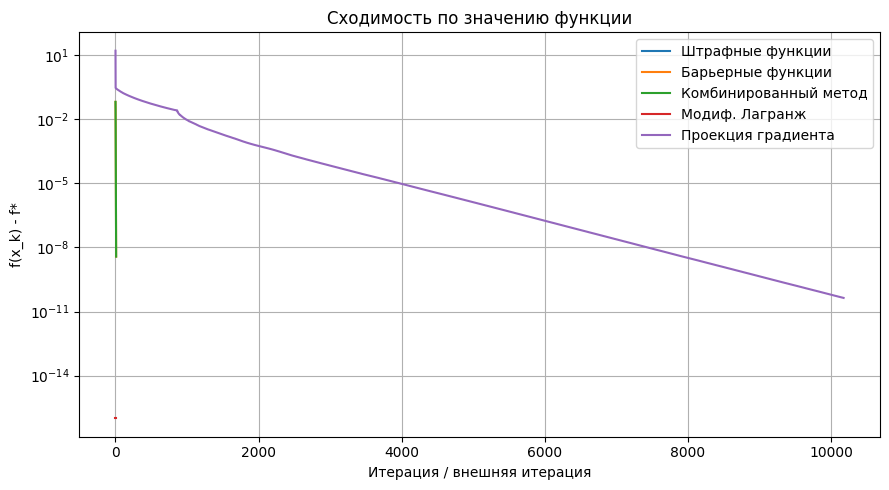

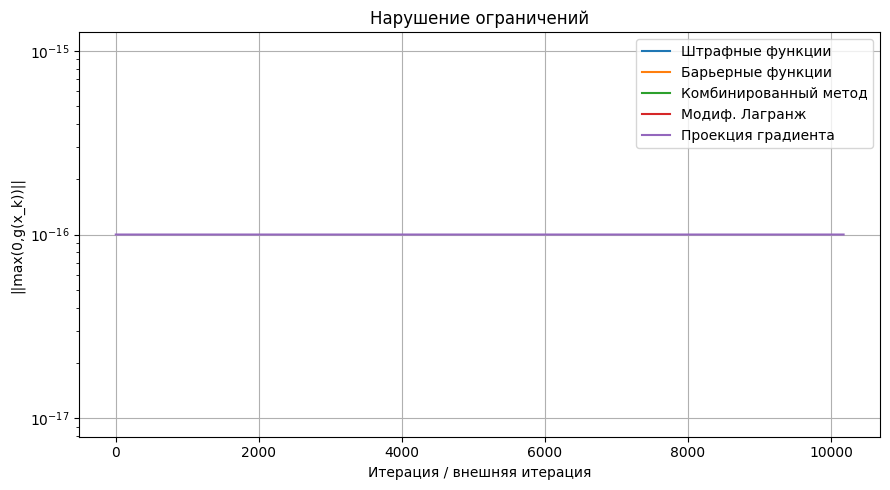

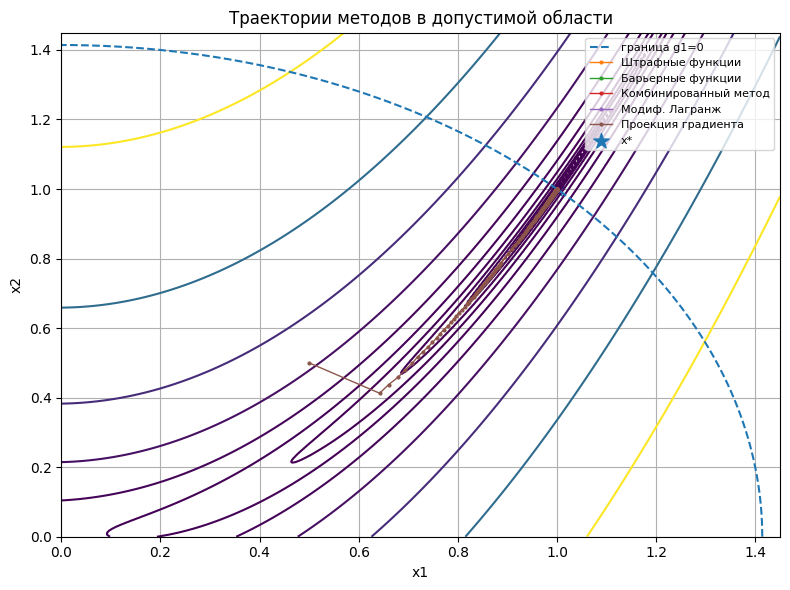

In [ ]:
x_star = np.ones(n)
f_star = f0

plt.figure(figsize=(9, 5))
for result in methods:
    f_values = [item['f'] for item in result['history']]
    iterations = list(range(len(f_values)))
    plt.plot(iterations, np.maximum(np.array(f_values) - f_star, 1e-16), label=result['method'])
plt.yscale('log')
plt.xlabel('Итерация / внешняя итерация')
plt.ylabel('f(x_k) - f*')
plt.title('Сходимость по значению функции')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('lab4_convergence_function.png', dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
for result in methods:
    violations = [item['viol'] for item in result['history']]
    iterations = list(range(len(violations)))
    plt.plot(iterations, np.maximum(np.array(violations), 1e-16), label=result['method'])
plt.yscale('log')
plt.xlabel('Итерация / внешняя итерация')
plt.ylabel('||max(0,g(x_k))||')
plt.title('Нарушение ограничений')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('lab4_constraint_violation.png', dpi=180)
plt.show()

# Траектории методов на линиях уровня.
x1_grid = np.linspace(0, 1.45, 250)
x2_grid = np.linspace(0, 1.45, 250)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        Z[i, j] = rosenbrock([X1[i, j], X2[i, j]])

plt.figure(figsize=(8, 6))
levels = f0 + np.logspace(-8, 2.5, 24)
plt.contour(X1, X2, Z, levels=levels)
theta = np.linspace(0, np.pi / 2, 300)
plt.plot(np.sqrt(R) * np.cos(theta), np.sqrt(R) * np.sin(theta), '--', label='граница g1=0')

for result in methods:
    xy = np.array([item['x'] for item in result['history']])
    if len(xy) > 500:
        idx = np.unique(np.r_[np.linspace(0, len(xy)-1, 500).astype(int), len(xy)-1])
        xy = xy[idx]
    plt.plot(xy[:, 0], xy[:, 1], marker='o', markersize=2, linewidth=1, label=result['method'])

plt.scatter([1], [1], marker='*', s=130, label='x*')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Траектории методов в допустимой области')
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('lab4_trajectories.png', dpi=180)
plt.show()
